In [1]:
import sys
# For notebooks inside research/ftir_hips_chem/:
sys.path.insert(0, './scripts')
# For notebooks under notebooks/ (e.g. plotting_gaps_scenarios.ipynb):
# sys.path.insert(0, '../research/ftir_hips_chem/scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Config + data
from config import (
    SITES, PROCESSED_SITES_DIR, FILTER_DATA_PATH,
    AERONET_DATA_DIR, WEATHER_DATA_DIR, MAC_VALUE,
)

# Exclusions (use these — do not hand-filter)
from outliers import (
    EXCLUDED_SAMPLES, MANUAL_OUTLIERS,
    apply_exclusion_flags, apply_threshold_flags,
    get_clean_data, print_exclusion_summary,
)

# Data loading / matching
from data_matching import (
    load_aethalometer_data, load_filter_data,
    match_aeth_filter_data, match_all_parameters,
)
from etad_factors import load_etad_factor_contributions, match_etad_factors

# External datasets — these resolve their own location, so do NOT hardcode a
# Drive path. Each checks an env var, then a config constant, then discovers the
# Drive mount: AETHMODULAR_AERONET_DIR / AETHMODULAR_IMPROVE_DIR.
from aeronet import load_aeronet, aeronet_dir, COLS as AERONET_COLS
from improve_io import load_improve_clean

# Plotting — importing the package auto-applies the white-background default
# style (apply_default_style()). Do NOT call plt.style.use('seaborn-v0_8-darkgrid')
# afterwards — it re-adds the grey axes facecolor we don't want.
from plotting import PlotConfig, crossplots, timeseries, distributions, comparisons
from plotting.utils import calculate_regression_stats

PlotConfig.set(sites='all', layout='individual', show_stats=False, show_1to1=False,
               figsize=(14.8, 6.2), font_size=20, title_size=23)

from IPython.display import display
from plotting.matched_sample_audit import MatchedSampleAuditFigures


# Matched-sample audit figures

Eight reproducible figures for the audit section of the weekly presentation. Run this active notebook from `research/ftir_hips_chem/` in the repository uv environment. The executed companion is saved under `notebooks/archive/executed/`.

This is an inventory and metadata audit, so all flags remain visible. The source audit already applies the exclusion registry non-destructively. We do not call `get_clean_data` to discard flagged records, do not re-match observations, and do not fit or validate a calibration. Each input hash must match the audit manifest before plotting.

Source report: `docs/matched-sample-audit-2026-09-10.md`. The figures use the canonical site colors and plotting defaults. Reusable figure code lives in `scripts/plotting/matched_sample_audit.py`. PNG and SVG exports go under `output/plots/matched_sample_audit/`, with plotted data and provenance under `output/tables/matched_sample_audit_figures/`.

In [2]:
audit = MatchedSampleAuditFigures()
display(audit.counts)

,physical_filters,hips_ftir_pairs,hips_ir_candidates,hips_window,ec_conflicts,excluded_pairs
site,,,,,,
Beijing,405,163,73,0,156,0
Delhi,120,63,25,0,27,1
JPL,306,130,68,130,142,0
Addis_Ababa,224,190,181,187,175,0


## 546 same-filter pairs, 347 IR date candidates

All finite HIPS/FTIR pairs appear here, including the registered Delhi exclusion. The darker bars are a subset with finite raw IR within the legacy ±1-calendar-day search. These 347 candidates do not establish a shared sampling interval or observed coverage. This catalog is separate from the 239-filter seasonal calibration cohort in the weekly presentation.

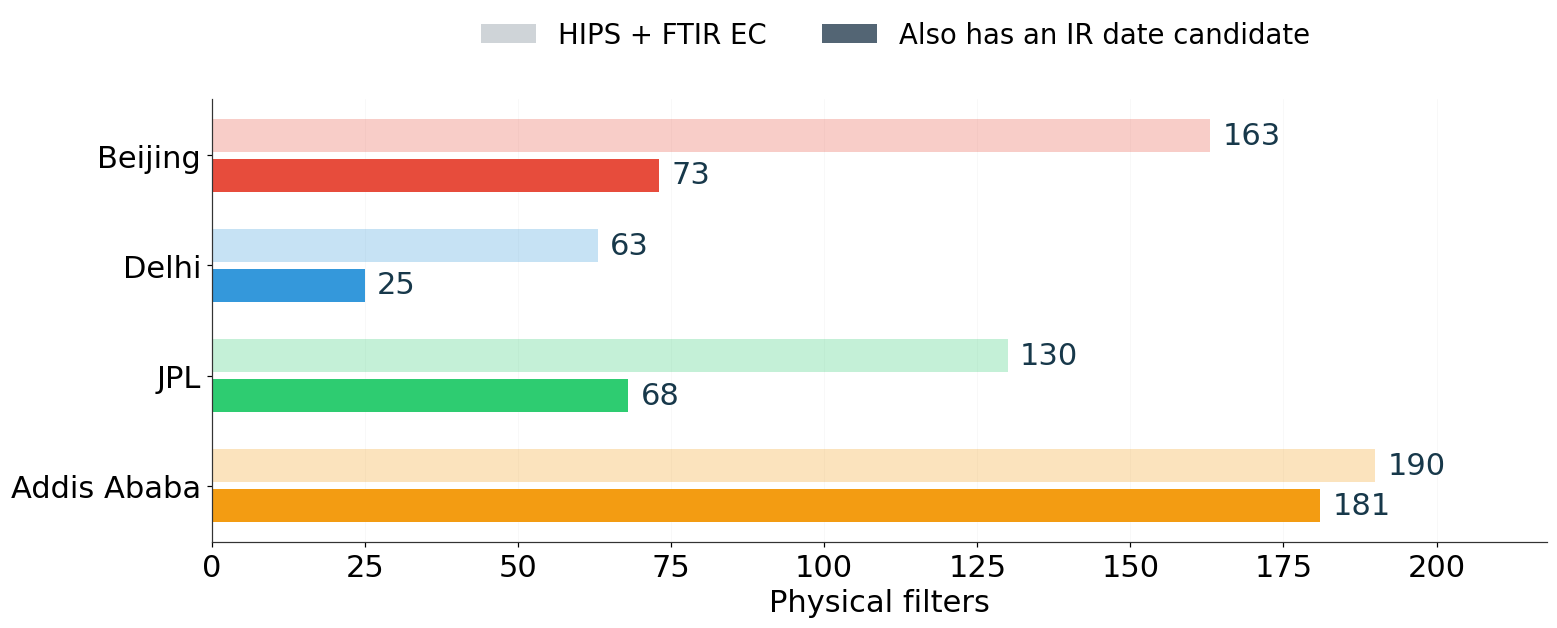

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/matched_sample_audit/01_pair_availability.png


In [3]:
fig = audit.pair_availability()
png = audit.save(fig, "01_pair_availability")
display(fig)
plt.close(fig)
print(png)

## 317 HIPS filters have recovered collection windows

Each complete bar contains the HIPS/FTIR pairs from the previous figure. Colored portions have positive-duration collection bounds recovered from portal records. Grey portions have no usable window in the inspected inputs. The current source directory supplied Addis and JPL exports only. Zeros for Beijing/Delhi describe that source coverage, not whether such metadata exist elsewhere. Recovered bounds still require active-period verification for intermittent collection.

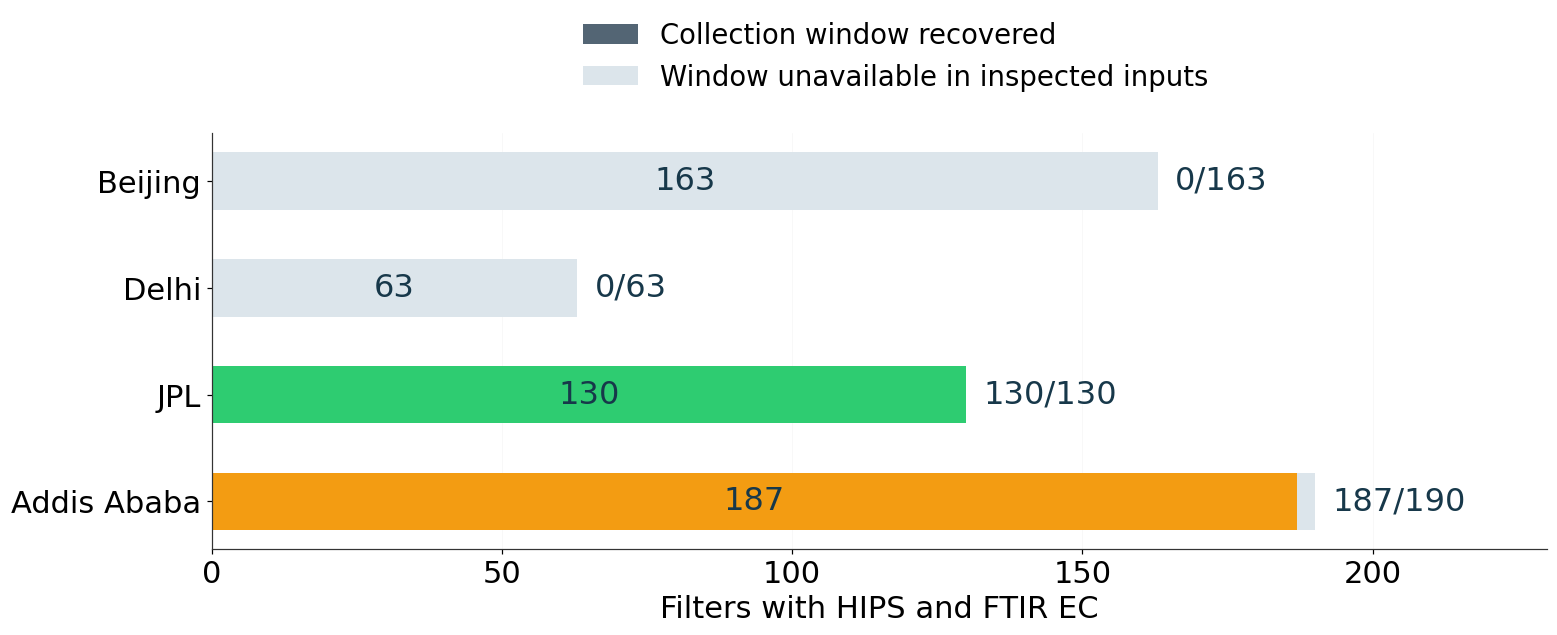

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/matched_sample_audit/02_metadata_availability.png


In [4]:
fig = audit.metadata_availability()
png = audit.save(fig, "02_metadata_availability")
display(fig)
plt.close(fig)
print(png)

## Saved timestamps cluster at 15:00

Labels give the complete saved row counts at each local hour. Marker area increases with count but every nonempty hour remains visible. The old builder shifted by 15 hours despite its 9 AM label. The corrected code now defines local [09:00, next 09:00) intervals and accounts for elapsed DST minutes. Existing saved files have not been rebuilt. Relabeling their timestamps would not repair their averages.

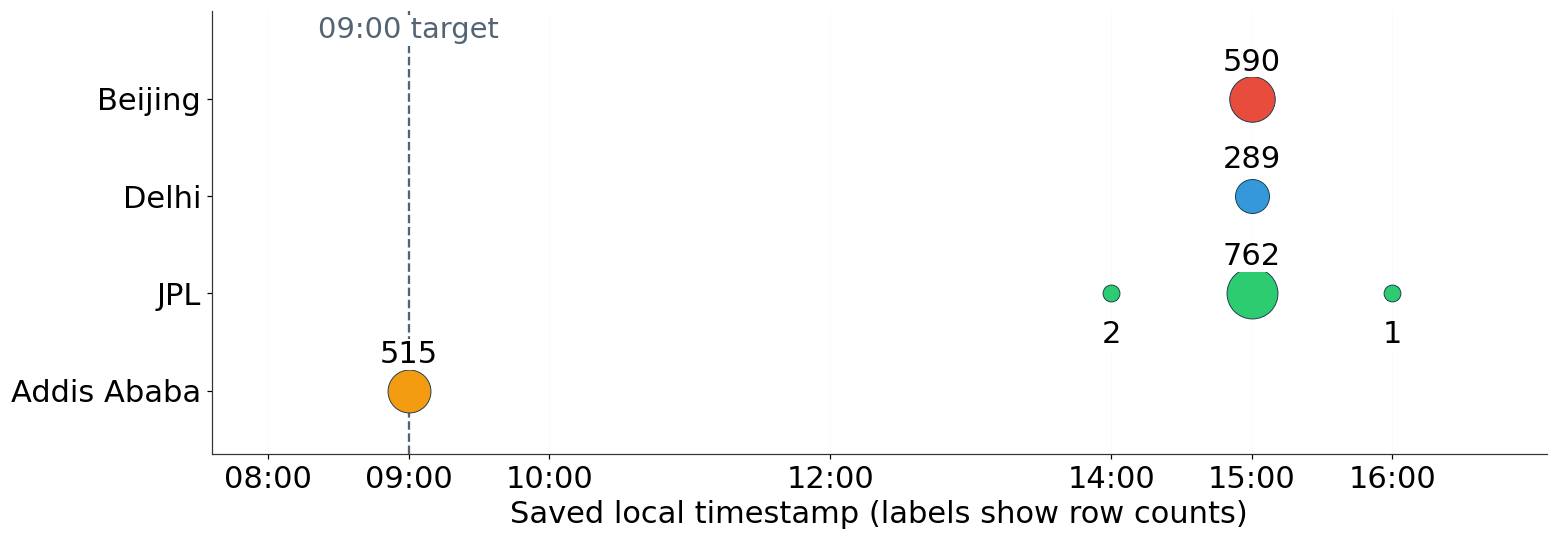

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/matched_sample_audit/03_timestamp_hours.png


In [5]:
fig = audit.timestamp_hours()
png = audit.save(fig, "03_timestamp_hours")
display(fig)
plt.close(fig)
print(png)

## Saved completeness needs an observation audit

Empirical cumulative distributions include all finite saved completeness values, including zeros and the value above 100%. Denominators are all saved rows for each represented site. Addis has no such field and does not receive an invented zero. The original field counted first-channel non-null records relative to 1,440 minutes. It does not verify observed IR minutes, duplicate handling, DST duration, or interpolation history. The corrected pipeline requires explicit observation provenance to distinguish observed minutes from mere input availability.

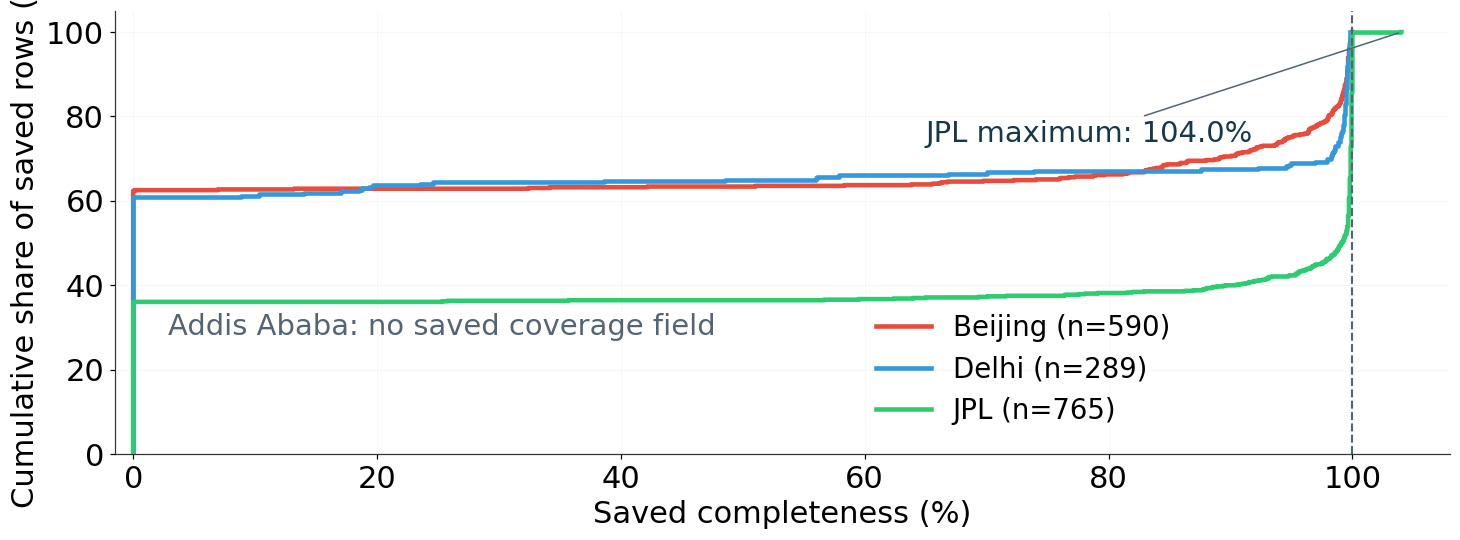

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/matched_sample_audit/04_completeness.png


In [6]:
fig = audit.completeness()
png = audit.save(fig, "04_completeness")
display(fig)
plt.close(fig)
print(png)

## 23 timing issues in 453 portal records

Hours agree means a positive-duration window and reported sampled hours agreeing within 0.05 hours. It is a metadata consistency check, not proof of continuous operation. All 453 portal filter records remain in the count: Addis 181 consistent, 6 differing, 1 invalid; JPL 249 consistent, 16 differing. The right panel enlarges the issue counts using the same denominators. The separate one-day SampleDate disagreement for ETAD-0243 is not counted as an additional record.

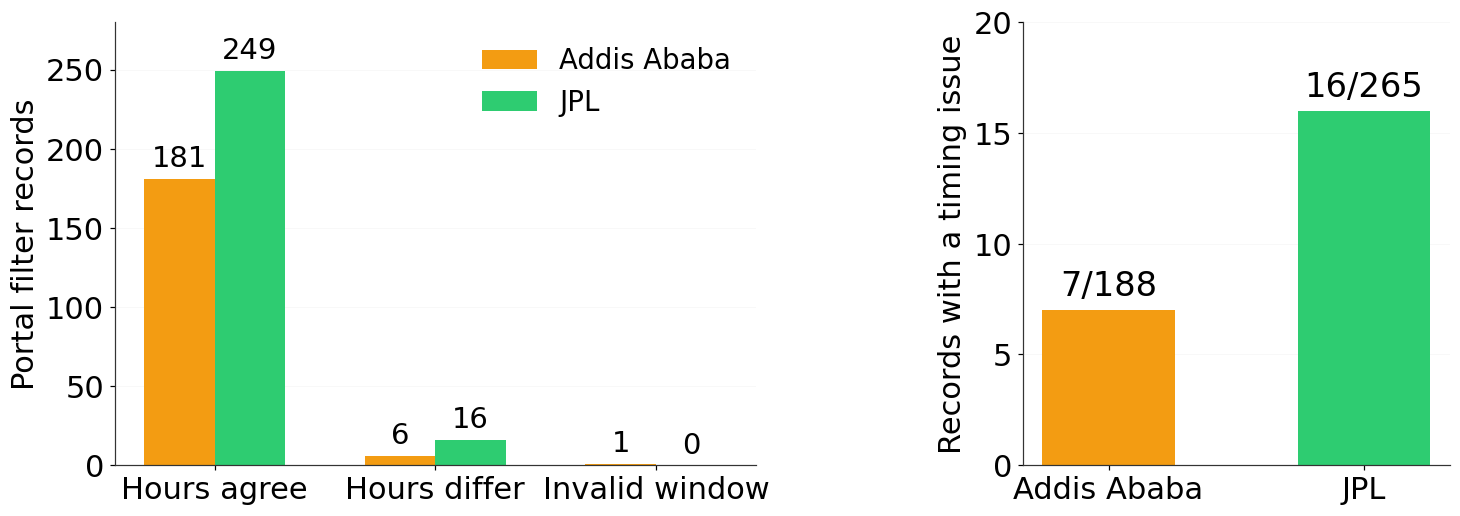

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/matched_sample_audit/05_timing_status.png


In [7]:
fig = audit.timing_status()
png = audit.save(fig, "05_timing_status")
display(fig)
plt.close(fig)
print(png)

## 20 filters span several days of collection

Every portal filter contributes to a duration group. Coincident points are grouped by site, elapsed hours and sampled hours, with marker area increasing with group count. The dashed segment denotes equal hours; no regression or validation statistic is fitted. The horizontal axis has a wider range than the vertical axis. Five Addis filters report 24 sampled hours across 192–216 elapsed hours; 15 JPL filters report 48 sampled hours across 237–238 elapsed hours. The other three timing issues are ETAD-0163 (24 vs 22.8 h), ETAD-0178 (0 vs 24 h), and USPA-0243 (23 vs 24 h). UTC differences account for the local JPL daylight-saving change.

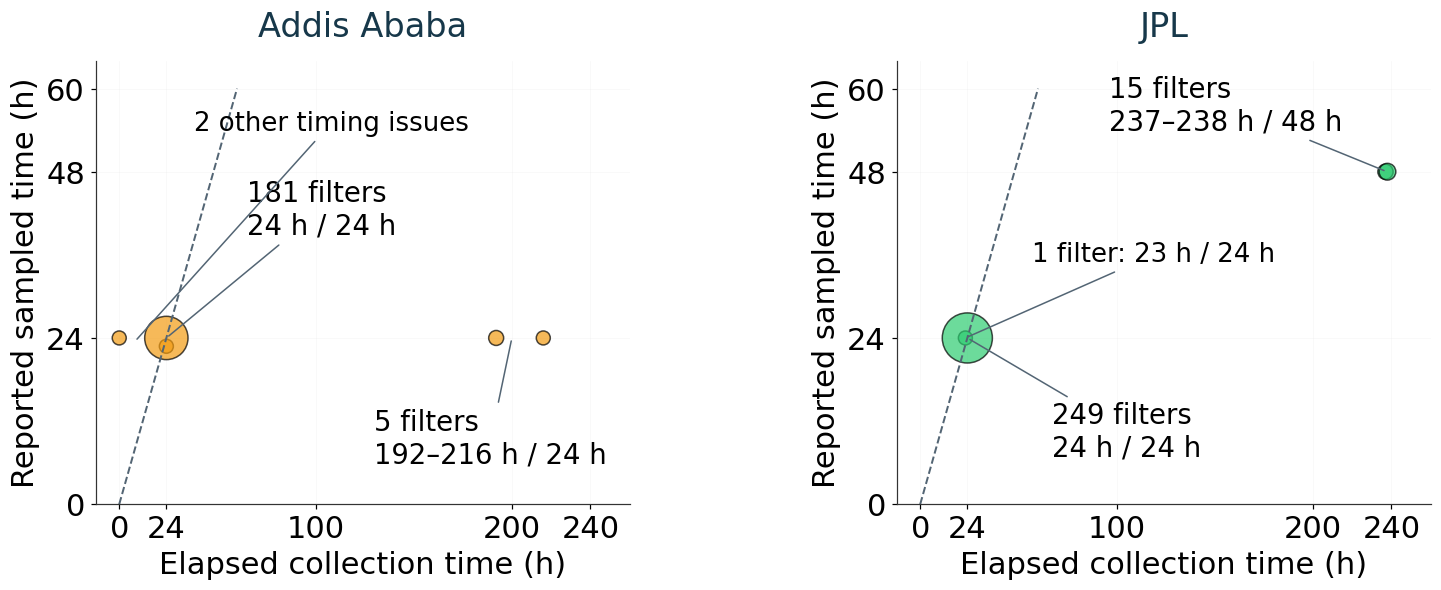

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/matched_sample_audit/06_collection_durations.png


In [8]:
fig = audit.collection_durations()
png = audit.save(fig, "06_collection_durations")
display(fig)
plt.close(fig)
print(png)

## Sampled hours cover only part of the collection window

Examples are selected explicitly to show the two intermittent patterns and an invalid record, not to estimate their prevalence. ETAD-0241 spans 7–15 August 2024 locally: 192 elapsed hours, 24 reported sampled hours. USPA-0329 spans 6–16 March 2024 locally: 237 elapsed hours, 48 sampled hours. ETAD-0178 reports identical local start/end on 24 February 2024 despite 24 sampled hours. The bars compare totals only. They do not place sampled hours at the beginning of the window or identify any active interval. Active on/off records are needed before computing a matched aethalometer mean.

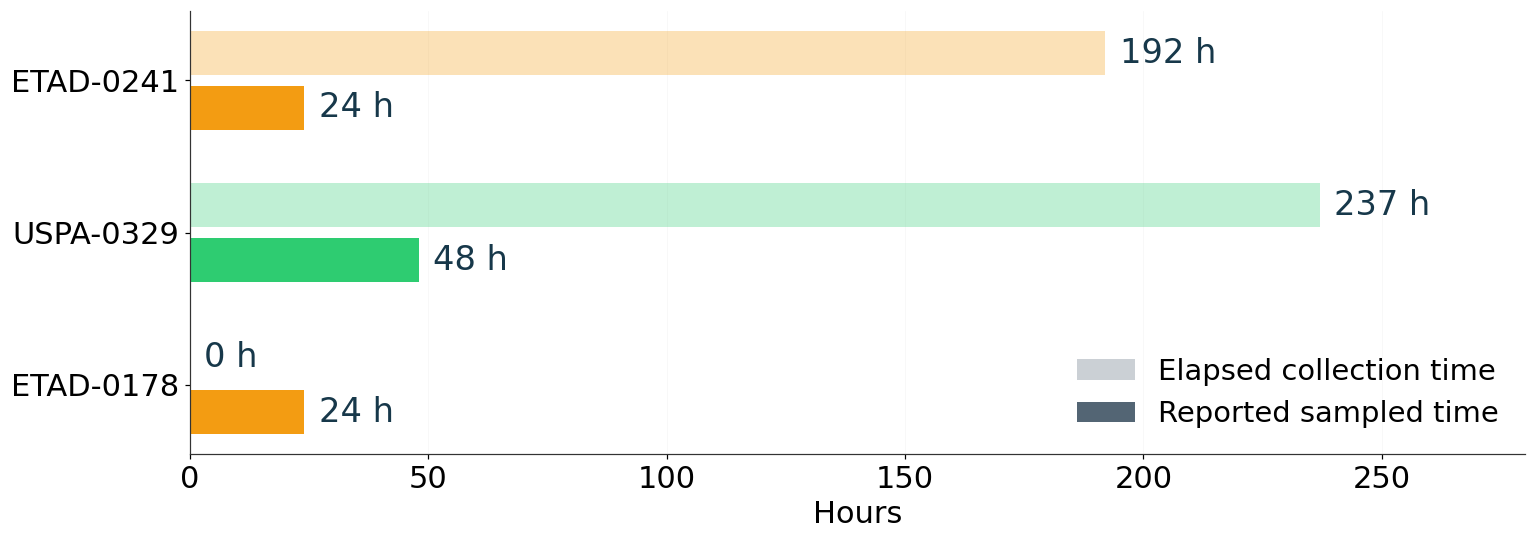

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/matched_sample_audit/07_duration_examples.png


In [9]:
fig = audit.duration_examples()
png = audit.save(fig, "07_duration_examples")
display(fig)
plt.close(fig)
print(png)

## 500 filters contain conflicting ChemSpec EC values

The left chart counts physical-filter groups whose ChemSpec_EC_PM2.5 concentrations conflict in the unified table. This is a count of inconsistent groups, not a count of independent EC references or chemically invalid filters. CHTS-0658 illustrates the issue: source rows 5859 and 5860 carry 0.93 and 0.06 µg/m³ under the same parameter name and calibration label. Source-row positions are zero-based iloc offsets in the hashed input. The audit retains both and does not average or choose the first value. Existing repository provenance work identifies the concentration product as FTIR EC and ChemSpec BC as HIPS/10, subject to rounding. Independent EC validation requires a separate reference. The next comparison needs resolved parameter definitions, active sampling intervals, observed coverage and optical conversions before evaluating adjustments in withheld calendar periods.

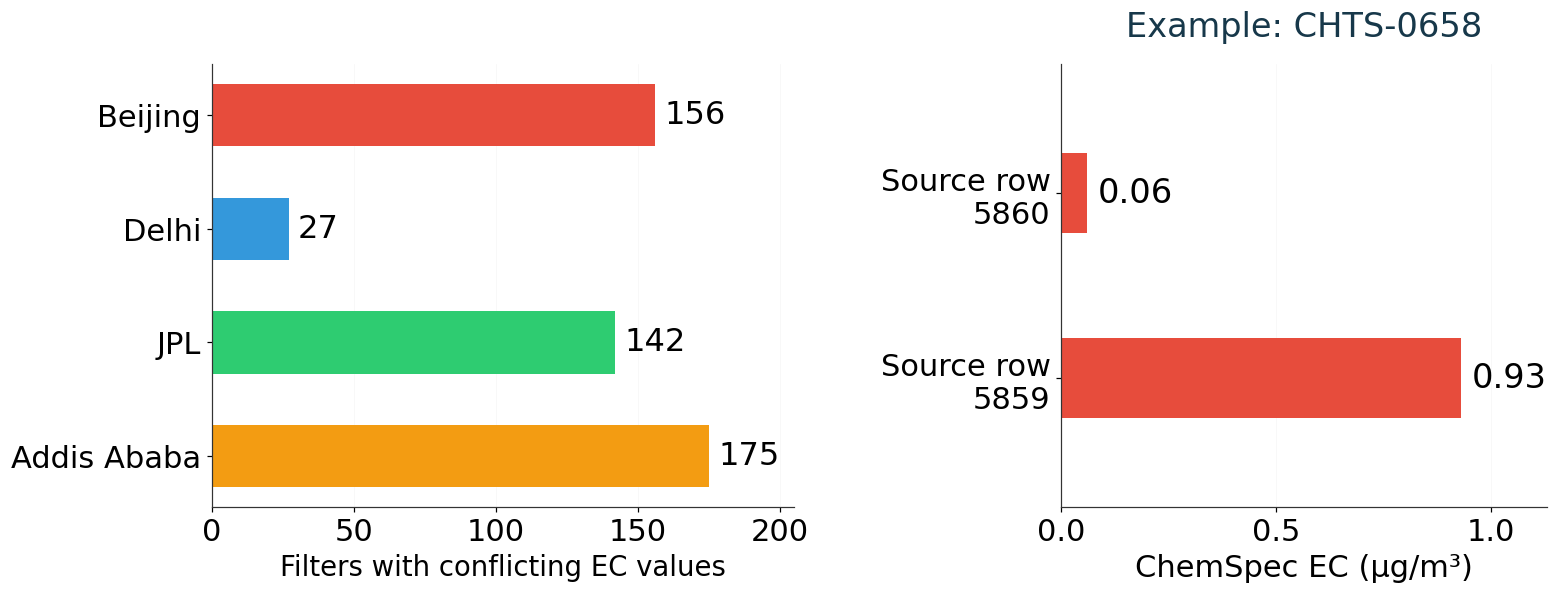

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/plots/matched_sample_audit/08_ec_conflicts.png


In [10]:
fig = audit.ec_conflicts()
png = audit.save(fig, "08_ec_conflicts")
display(fig)
plt.close(fig)
print(png)

In [11]:
manifest_path = audit.write_manifest()
print(manifest_path)

/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/tables/matched_sample_audit_figures/figure_manifest.json


## Source definitions

All measurements, row links, recovered collection bounds and registered flags come from `output/tables/matched_sample_audit/`. The coverage figure reads the four saved pickles identified by `config.SITES` and checks them against the same manifest. ChemSpec provenance is documented in `docs/open-items.md`. No on/off schedule or independent EC reference is inferred from the displayed counts.